# Session 2 — Solutions

Worked solutions for object selection and b-tagging exercises. Run Session 1 solutions first, or run the cell below to load events from the 2017 config.

## Full selection and plots (Ex 2.1–2.6)


In [3]:
import sys
sys.path.append("..")
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

from coffea.nanoevents import NanoEventsFactory, NanoAODSchema

def load_events(filepath):
    """Load one NanoAOD ROOT file and return a NanoEvents object.

    - **Why NanoEvents?** It maps flat NanoAOD branches like `Jet_pt`, `MET_pt` into
      convenient collections like `events.Jet.pt`, `events.MET.pt` using Awkward Arrays.
    """
    return NanoEventsFactory.from_root(filepath, schemaclass=NanoAODSchema).events()

# Load events
from config.datasets_2017 import get_one_file_per_group_from_yaml
try:
    files = get_one_file_per_group_from_yaml()
    # We load one *data* file (MET run) and one *MC background* file.
    events = load_events(files["background"][0])
    print("Files Loaded:\n",files)
except Exception as e:
    print("Could not load events.")
    print(e)


/cvmfs/sft.cern.ch/lcg/views/LCG_105a_swan/x86_64-el9-gcc13-opt/lib/python3.9/site-packages/coffea/nanoevents/schemas/nanoaod.py:201: RuntimeWarning: Missing cross-reference index for FatJet_genJetAK8Idx => GenJetAK8
  warnings.warn(
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_swan/x86_64-el9-gcc13-opt/lib/python3.9/site-packages/coffea/nanoevents/schemas/nanoaod.py:201: RuntimeWarning: Missing cross-reference index for FsrPhoton_muonIdx => Muon
  warnings.warn(
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_swan/x86_64-el9-gcc13-opt/lib/python3.9/site-packages/coffea/nanoevents/schemas/nanoaod.py:201: RuntimeWarning: Missing cross-reference index for Muon_fsrPhotonIdx => FsrPhoton
  warnings.warn(


Files Loaded:
 {'data': ['/eos/cms/store/group/phys_susy/sus-23-008/cmsdas2026/2017/SingleElectron-Run2017B-02Apr2020-v1/08B5DC81-D780-A54B-80FE-C94EBD267ACA.root'], 'background': ['/eos/cms/store/group/phys_susy/sus-23-008/cmsdas2026/2017/WJetsToLNu_HT-400To600_TuneCP5_13TeV-madgraphMLM-pythia8-RunIIFall17NanoAOD-PU2017_12Apr2018_94X_mc2017_realistic_v14-v1/0209439B-D65A-E811-8708-A4BF01125A90.root']}


In [4]:
# --- Object selection working points (typical Run-2 choices) ---
JET_PT_MIN = 30.0
JET_ETA_MAX = 2.4
BTAG_WP_MEDIUM = 0.2783
LEP_PT_MIN = 10.0
LEP_ETA_MAX_EL = 2.5
LEP_ETA_MAX_MU = 2.4


def select_good_jets(events):
    """Baseline jet selection.

    - pT and |eta| define the kinematic acceptance (tracker coverage is important for b-tagging).
    - `jetId >= 2` enforces "tight" jet ID to remove noise / poorly reconstructed jets.
    """
    jets = events.Jet
    mask = (jets.pt > JET_PT_MIN) & (np.abs(jets.eta) < JET_ETA_MAX) & (jets.jetId >= 2)
    return jets[mask]


def count_bjets(jets, wp=BTAG_WP_MEDIUM):
    """Count b-tagged jets per event using DeepJet/DeepFlavB discriminator.

    This is an *event-level* quantity: sum over jets (axis=1).
    """
    return ak.sum(jets.btagDeepFlavB > wp, axis=1)


def select_tight_electrons(events):
    """Select tight electrons.

    `cutBased` encodes identification quality; `>= 2` corresponds to a "tight-ish" ID.
    """
    ele = events.Electron
    mask = (ele.pt > LEP_PT_MIN) & (np.abs(ele.eta) < LEP_ETA_MAX_EL) & (ele.cutBased >= 2)
    return ele[mask]


def select_tight_muons(events):
    """Select tight, isolated muons.

    - `tightId` ensures muon quality.
    - `pfRelIso04_all < 0.15` enforces isolation (reduces heavy-flavor/nonprompt leptons).
    """
    mu = events.Muon
    mask = (mu.pt > LEP_PT_MIN) & (np.abs(mu.eta) < LEP_ETA_MAX_MU) & (mu.tightId) & (mu.pfRelIso04_all < 0.15)
    return mu[mask]


def n_tight_leptons(events):
    """Total tight-lepton multiplicity per event (electrons + muons)."""
    nele = ak.count(select_tight_electrons(events).pt, axis=1)
    nmu = ak.count(select_tight_muons(events).pt, axis=1)
    return nele + nmu


# Apply object selections and build per-event observables.
# `ak.num` gives jet multiplicity per event; `count_bjets` gives b-jet multiplicity.
good_jets = select_good_jets(events)
njets = ak.num(good_jets)
nbjets = count_bjets(good_jets)
nlep = n_tight_leptons(events)

print("Mean jets/event:", ak.mean(njets))
print("Events with >=2 b-jets:", ak.sum(nbjets >= 2))
print("Events with 0 leptons:", ak.sum(nlep == 0))

Mean jets/event: 3.49685534591195
Events with >=2 b-jets: 22
Events with 0 leptons: 822


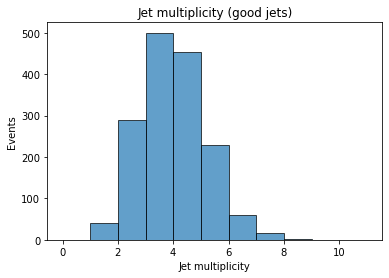

In [5]:
# Jet multiplicity (Ex 2.4)
# This checks how our baseline jet selection changes event composition.
plt.figure()
plt.hist(ak.to_numpy(njets), bins=range(12), edgecolor="black", alpha=0.7)
plt.xlabel("Jet multiplicity")
plt.ylabel("Events")
plt.title("Jet multiplicity (good jets)")
plt.show()

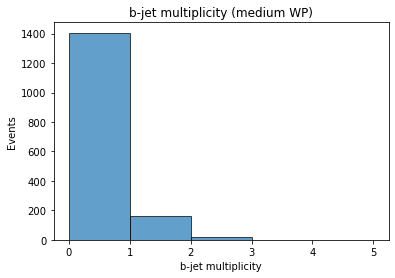

In [6]:
# b-jet multiplicity (Ex 2.2, 2.5)
# b-tagging is key in bb+MET: requiring >=2 b-jets suppresses light-flavor backgrounds.
plt.figure()
plt.hist(ak.to_numpy(nbjets), bins=range(6), edgecolor="black", alpha=0.7)
plt.xlabel("b-jet multiplicity")
plt.ylabel("Events")
plt.title("b-jet multiplicity (medium WP)")
plt.show()

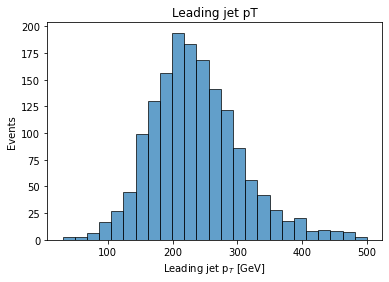

In [7]:
# Leading jet pT (Ex 2.6)
# The leading jet pT is often correlated with MET and helps validate jet selection.
# `ak.firsts` picks the first jet per event (jets are already pT-sorted in NanoAOD).
lead_pt = ak.fill_none(ak.firsts(good_jets.pt), 0.0)

plt.figure()
plt.hist(ak.to_numpy(lead_pt), bins=25, range=(30, 500), edgecolor="black", alpha=0.7)
plt.xlabel("Leading jet p$_T$ [GeV]")
plt.ylabel("Events")
plt.title("Leading jet pT")
plt.show()